In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv('/content/all_exoplanets_2021.csv.crdownload')

In [ ]:
df.size

105225

In [ ]:
df.isnull().sum()

,0
No.,0
Planet Name,0
Planet Host,0
Num Stars,0
Num Planets,0
Discovery Method,0
Discovery Year,0
Discovery Facility,0
Orbital Period Days,162
Orbit Semi-Major Axis,1812


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4575 entries, 0 to 4574
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   No.                            4575 non-null   int64  
 1   Planet Name                    4575 non-null   object 
 2   Planet Host                    4575 non-null   object 
 3   Num Stars                      4575 non-null   int64  
 4   Num Planets                    4575 non-null   int64  
 5   Discovery Method               4575 non-null   object 
 6   Discovery Year                 4575 non-null   int64  
 7   Discovery Facility             4575 non-null   object 
 8   Orbital Period Days            4413 non-null   float64
 9   Orbit Semi-Major Axis          2763 non-null   float64
 10  Mass                           2006 non-null   float64
 11  Eccentricity                   1707 non-null   float64
 12  Insolation Flux                370 non-null    f

In [ ]:
df = df.drop(['No.', 'Planet Name', 'Planet Host',
              'Discovery Method', 'Discovery Facility',
              'Spectral Type', 'Stellar Metallicity Ratio'], axis=1, errors='ignore')

Handling missing values(i used median)

In [ ]:
num_cols = df.select_dtypes(include=['float64','int64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


In [ ]:
def habitability_label(row):
    score = 0

    # Rule 1: Distance
    if 0.95 <= row['Orbit Semi-Major Axis'] <= 1.37:
        score += 1

    # Rule 2: Temperature
    if 250 <= row['Equilibrium Temperature'] <= 330:
        score += 1

    # Rule 3: Mass
    if 0.1 <= row['Mass'] <= 5:
        score += 1

    return 1 if score >= 2 else 0


df['Habitability'] = df.apply(habitability_label, axis=1)


In [ ]:
df.head(5)

,Num Stars,Num Planets,Discovery Year,Orbital Period Days,Orbit Semi-Major Axis,Mass,Eccentricity,Insolation Flux,Equilibrium Temperature,Stellar Effective Temperature,Stellar Radius,Stellar Mass,Stellar Metallicity,Stellar Surface Gravity,Distance,Gaia Magnitude,Habitability
0,2,1,2007,326.03000,1.29,6165.6000,0.231,45.7,961.0,4742.0,19.00,2.70,-0.35,2.31,93.1846,4.44038,0
1,1,1,2009,516.21997,1.53,4684.8142,0.080,45.7,961.0,4213.0,29.79,2.78,-0.02,1.93,125.3210,4.56216,0
2,1,1,2008,185.84000,0.83,1525.5000,0.000,45.7,961.0,4813.0,11.00,2.20,-0.24,2.63,75.4392,4.91781,0
3,1,2,2002,1773.40002,2.93,1481.0878,0.370,45.7,961.0,5338.0,0.93,0.90,0.41,4.45,17.9323,6.38300,0
4,3,1,1996,798.50000,1.66,565.7374,0.680,45.7,961.0,5750.0,1.13,1.08,0.06,4.36,21.1397,6.06428,0


In [ ]:
df.sample(5)

,Num Stars,Num Planets,Discovery Year,Orbital Period Days,Orbit Semi-Major Axis,Mass,Eccentricity,Insolation Flux,Equilibrium Temperature,Stellar Effective Temperature,Stellar Radius,Stellar Mass,Stellar Metallicity,Stellar Surface Gravity,Distance,Gaia Magnitude,Habitability
74,1,1,2019,8.989100,0.1151,3686.82800,0.250,45.7,961.0,5574.0,0.96,0.90,0.020,4.45,157.998,12.1454,0
2400,1,2,2014,28.551383,0.1580,220.88734,0.092,45.7,961.0,4623.0,0.62,0.96,0.020,4.66,315.177,14.4165,0
3977,1,1,2016,8.088014,0.1151,220.88734,0.092,45.7,961.0,5310.0,0.83,0.87,-0.020,4.54,576.503,14.6250,0
3731,1,4,2014,81.065900,0.3860,4.10000,0.012,45.7,961.0,6174.0,1.30,1.17,-0.073,4.27,1020.720,13.8825,0
2455,1,1,2016,3.290305,0.1151,220.88734,0.092,45.7,961.0,3636.0,0.47,0.50,0.060,4.78,258.979,15.6681,0


In [ ]:
df['Habitability'].value_counts()

,count
Habitability,
0,4567
1,8


In [ ]:
X = df.drop('Habitability', axis=1)
y = df['Habitability']


outliers

In [ ]:
num_cols = X.select_dtypes(include=['float64','int64']).columns

for col in num_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    X[col] = np.clip(X[col], lower, upper)

Encode Categorical Features
One-hot encoding:

In [ ]:
cat_cols = df.select_dtypes(include='object').columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

Feature Engineering
 (A) Habitability Score Index (HSI)

In [ ]:
df["Habitability_Score"] = (
    0.3 * (1 / (1 + abs(df["Orbit Semi-Major Axis"] - 1))) +
    0.3 * (1 / (1 + abs(df["Equilibrium Temperature"] - 288)))) + \
    0.2 * (1 / (1 + abs(df["Mass"] - 1))) + \
    0.2 * (1 / (1 + abs(df["Stellar Effective Temperature"] - 5778)))


(B) Stellar Compatibility Index (SCI)

In [ ]:
df["Stellar_Compatibility"] = (
    0.4 * (1 / (1 + abs(df["Stellar Effective Temperature"] - 5778))) +
    0.3 * (1 / (1 + abs(df["Stellar Metallicity"] - 0.0))) +
    0.3 * (1 / (1 + abs(df["Stellar Radius"] - 1))))


Normalize Numerical Features

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])


Validate Data Quality

In [ ]:
#Descriptive statistics:
df.describe()


,Num Stars,Num Planets,Discovery Year,Orbital Period Days,Orbit Semi-Major Axis,Mass,Eccentricity,Insolation Flux,Equilibrium Temperature,Stellar Effective Temperature,Stellar Radius,Stellar Mass,Stellar Metallicity,Stellar Surface Gravity,Distance,Gaia Magnitude,Habitability,Habitability_Score,Stellar_Compatibility
count,4.575000e+03,4.575000e+03,4.575000e+03,4.575000e+03,4.575000e+03,4.575000e+03,4.575000e+03,4.575000e+03,4.575000e+03,4.575000e+03,4.575000e+03,4.575000e+03,4.575000e+03,4.575000e+03,4.575000e+03,4.575000e+03,4575.000000,4575.000000,4575.000000
mean,8.076114e-17,-1.180355e-16,2.030211e-14,3.106198e-18,1.242479e-17,2.484958e-17,3.727437e-17,6.212396e-18,8.697354e-17,-1.149293e-16,-2.484958e-17,6.212396e-17,1.747236e-17,-1.304603e-15,4.969916e-17,-4.969916e-17,0.001749,0.166907,0.517589
std,1.000109e+00,1.000109e+00,1.000109e+00,1.000109e+00,1.000109e+00,1.000109e+00,1.000109e+00,1.000109e+00,1.000109e+00,1.000109e+00,1.000109e+00,1.000109e+00,1.000109e+00,1.000109e+00,1.000109e+00,1.000109e+00,0.041785,0.040275,0.068127
min,-3.126658e-01,-6.753401e-01,-6.530240e+00,-1.539820e-02,-4.687915e-02,-4.801649e-01,-9.955631e-01,-1.105619e-01,-3.646710e+00,-3.570166e+00,-4.046339e-01,-2.212137e+00,-6.755004e+00,-7.887963e+00,-7.003466e-01,-3.245494e+00,0.000000,0.000366,0.156366
25%,-3.126658e-01,-6.753401e-01,-2.178899e-01,-1.539744e-02,-4.628509e-02,-2.402047e-01,-2.023719e-01,-4.592474e-02,-7.670607e-02,-2.943995e-01,-1.842887e-01,-3.240348e-01,-2.332387e-01,-1.371408e-01,-5.637277e-01,-5.215927e-01,0.000000,0.158083,0.489063
50%,-3.126658e-01,-6.753401e-01,2.870981e-01,-1.539624e-02,-4.609859e-02,-2.402047e-01,-2.023719e-01,-4.592474e-02,-7.670607e-02,9.122169e-02,-1.429739e-01,-2.470160e-02,3.295575e-02,1.858101e-01,-2.333467e-01,3.031361e-01,0.000000,0.161170,0.530009
75%,-3.126658e-01,1.819521e-01,2.870981e-01,-1.539174e-02,-4.579609e-02,-2.402047e-01,-2.023719e-01,-4.592474e-02,-7.670607e-02,3.182731e-01,-7.411606e-02,2.516060e-01,2.991502e-01,4.093915e-01,2.120316e-01,7.743806e-01,0.000000,0.170599,0.563236
max,8.218820e+00,5.325705e+00,1.549568e+00,6.760669e+01,5.287887e+01,1.871530e+01,7.194998e+00,6.347854e+01,1.202839e+01,2.530565e+01,2.267377e+01,2.295488e+01,3.526758e+00,8.806115e+00,8.132889e+00,2.625445e+00,1.000000,0.399902,0.994118


Missing values heatmap:

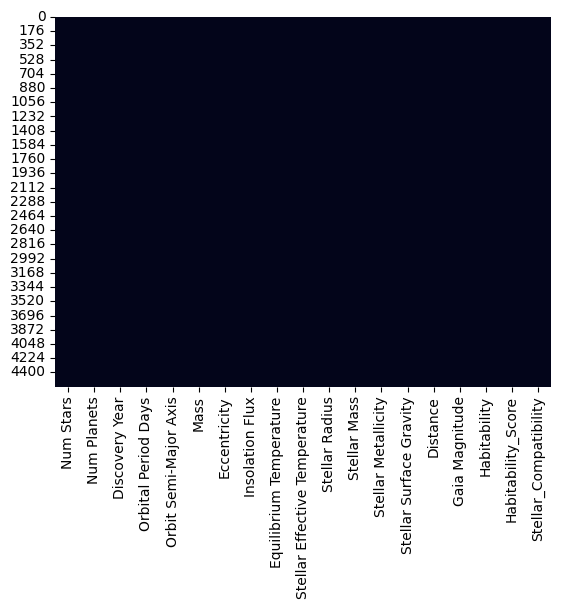

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.isnull(), cbar=False)
plt.show()


Distribution plots (univariate):

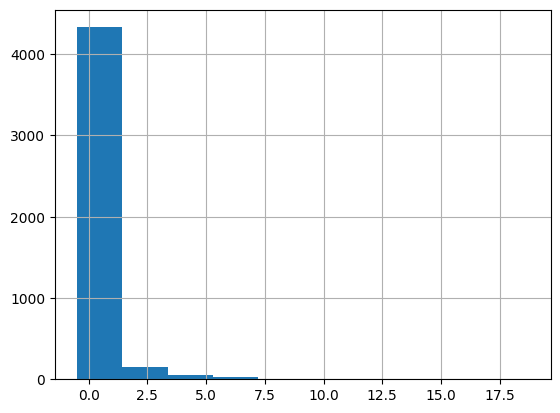

In [ ]:
df['Mass'].hist()
plt.show()

Bivariate plots:

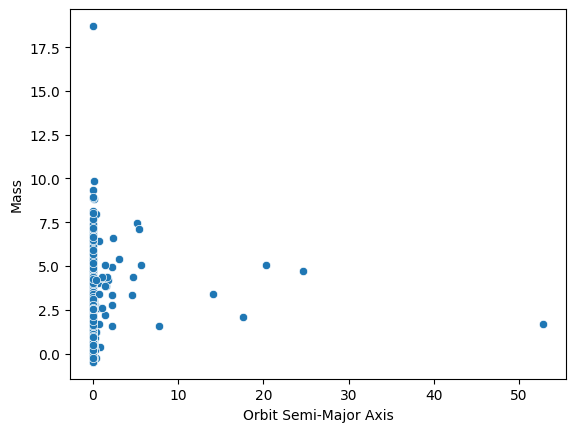

In [ ]:
sns.scatterplot(data=df, x="Orbit Semi-Major Axis", y="Mass")
plt.show()

Apply SMOTE + Tomek Links

In [ ]:
from imblearn.combine import SMOTETomek

X = df.drop('Habitability', axis=1)
y = df['Habitability']

smote_tomek = SMOTETomek()

X_resampled, y_resampled = smote_tomek.fit_resample(X, y)

print("After balancing:")
print(y_resampled.value_counts())

After balancing:
Habitability
0    4564
1    4564
Name: count, dtype: int64


SMOTE only

In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE()
X_res, y_res = sm.fit_resample(X, y)
print(y_res.value_counts())


Habitability
0    4567
1    4567
Name: count, dtype: int64


Random Undersampling- reduce the majority class(but we lose imp data)

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler()
X_res, y_res = rus.fit_resample(X, y)
print(y_res.value_counts())


Habitability
0    8
1    8
Name: count, dtype: int64


Class Weights (no balancing required)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight='balanced')
model.fit(X, y)


RandomForestClassifier(class_weight='balanced')

Anomaly Detection (best when minority < 1%)

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.002)  # ~8/4567
iso.fit(X)

anomaly_scores = iso.predict(X)
